# Hillik: a consistent High-&ell; likelihood

[``Hillik``](#https://github.com/mtristram/hillik) is a CMB likelihood based on cross-power spectra which can accomodate spectra from different survey (Planck, SPT, ACT) within a common modelisation of the foreground residuals.\
The likelihood is a Gaussian approximation with a signal model including CMB, galactic emissions (dust), poisson noise (from unmasked point sources) and extra-galactic emissions (tSZ, CIB, kSZ, SZxCIB).\
Nuisance parameters (calibration, polar efficiency, T-E-B leakage, ...) are associated to each survey with the exact same treatment as in the original studies.

In [2]:
import MCtools
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = arange(len(clth[0]))

## Models

### Planck

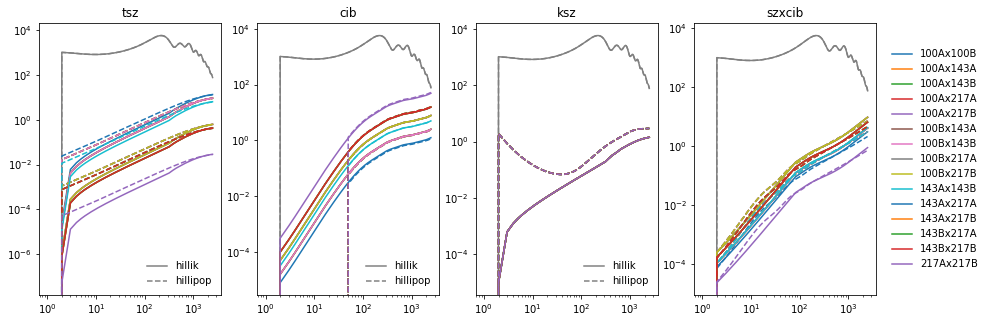

In [31]:
import itertools
xfreq = list(itertools.combinations( ['100A','100B','143A','143B','217A','217B'],2))

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_plk_fgs.npy")))
fg_list = ["dust","tsz","ksz","cib","szxcib","ps_radio","ps_dusty","ps"]
hlp = dict( zip(fg_list,np.load( f"{DBdir}/../hillipop_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','hillipop'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label="%sx%s" % xfreq[c])
        p2=plot( abs(hlp[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### SPT

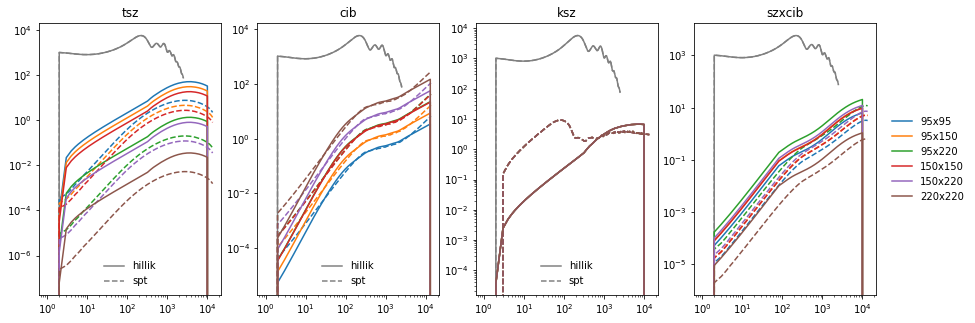

In [30]:
xfreq = ["95x95","95x150","95x220","150x150","150x220","220x220"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_spt_fgs.npy")))
fg_list = ["ps_dg","cib","ps_rg","tsz","ksz","dust","szxcib","szxradio"]
spt = dict( zip(fg_list,np.load( f"{DBdir}/../spt_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','spt'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(spt[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (deep)

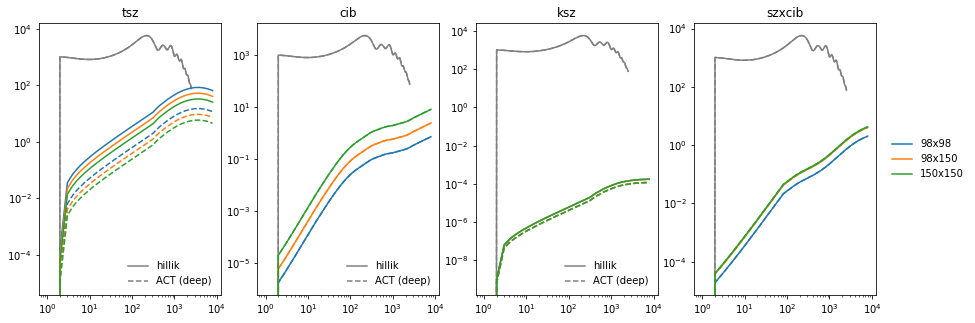

In [28]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTd_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_deep_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (deep)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (wide)

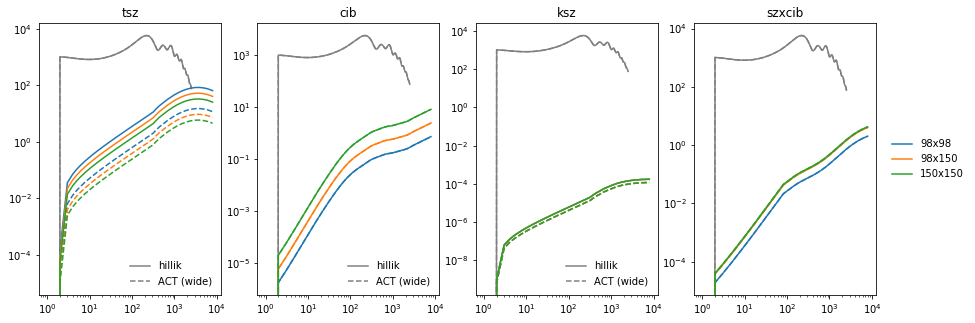

In [29]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTw_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_wide_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (wide)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

## Each survey

In [6]:
runnames = ['hillik_plk','hillik_spt','hillik_act']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.8, nelts=20000) for run in runnames]

hillik_plk: 238935  211920  219924  180305 
hillik_spt: 493681  408801  347201  498961 
hillik_act: 318241  352605  263121  329014 


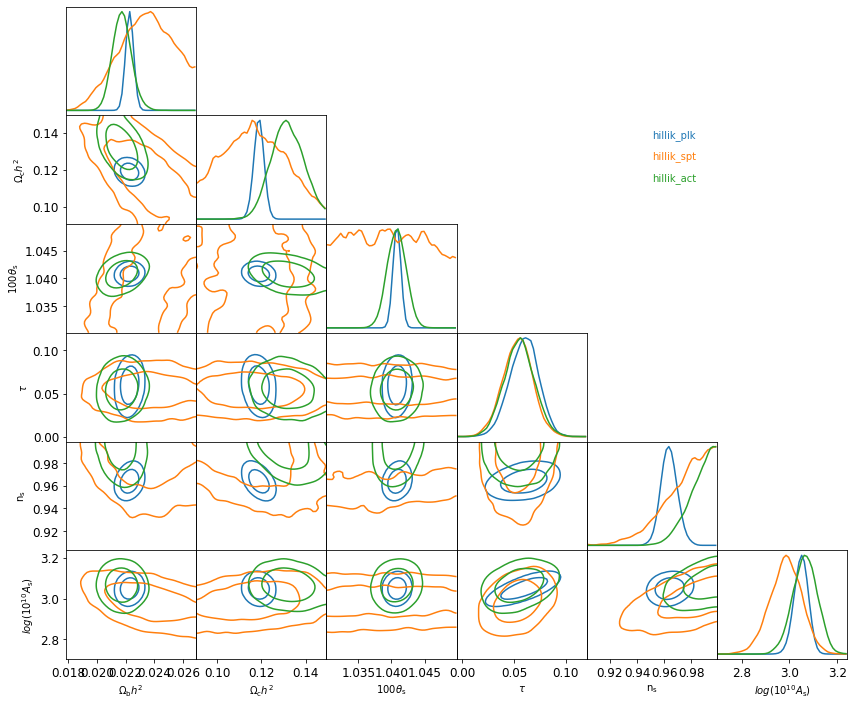

In [7]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

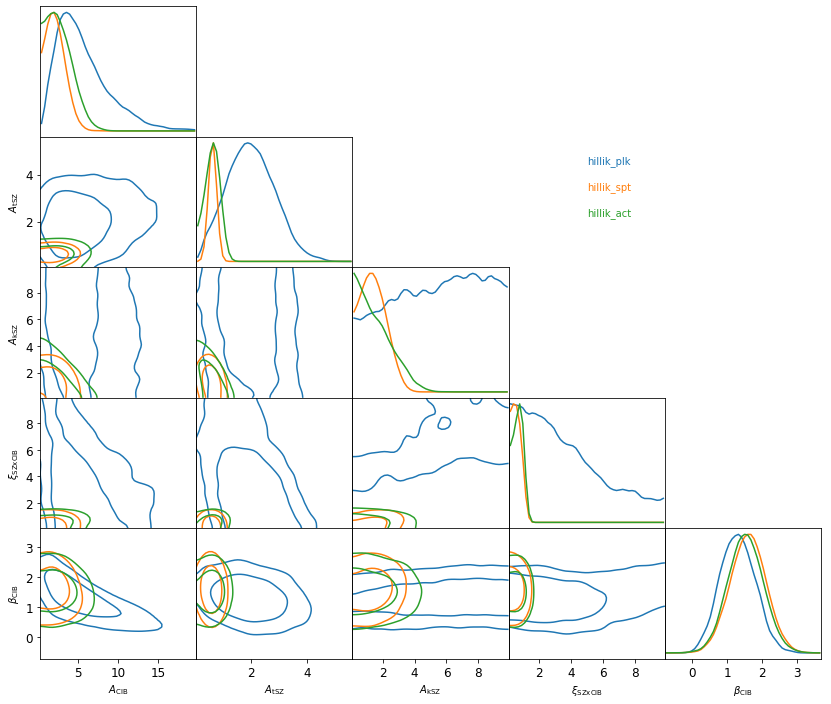

In [8]:
#extra-galactic fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Combination

In [3]:
runnames = ['hillik_plk','hillik_plkspt','hillik_plkact','hillik_plksptact']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]

hillik_plk: 240359  213229  221470  181271 
hillik_plkspt: 551829  473754  619587  494277 
hillik_plkact: 657729  637442  635186  763395 
hillik_plksptact: 639955  588525  1228331  631470 


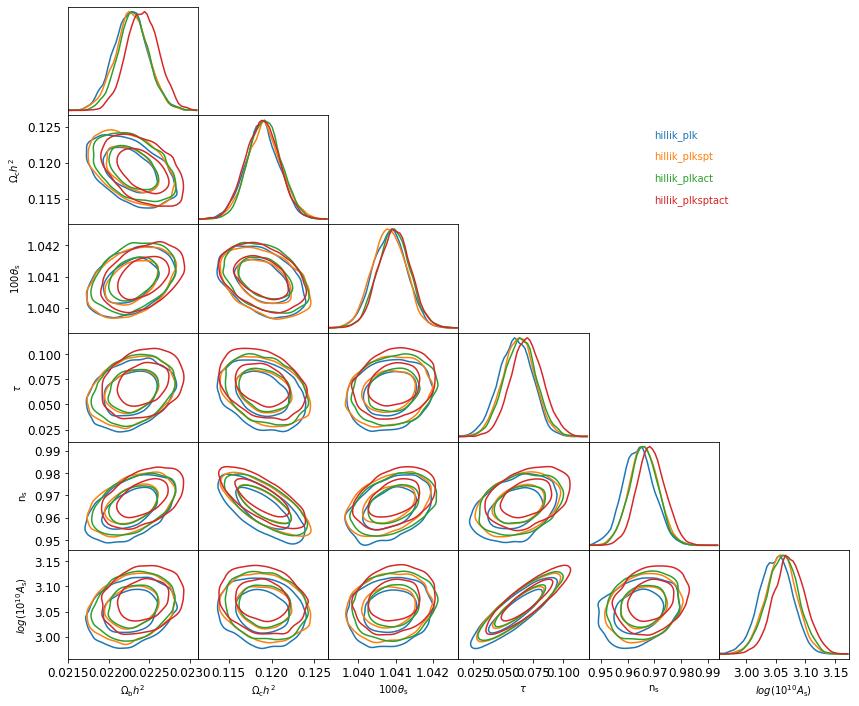

In [4]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)

In [5]:
print( "%35s %28s %28s %28s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

                         hillik_plk                hillik_plkspt                hillik_plkact             hillik_plksptact
ombh2           =  0.022271 +/- 0.000214  |   0.022285 +/- 0.000204  |   0.022305 +/- 0.000187  |   0.022422 +/- 0.000198
omch2           =  0.118862 +/- 0.001983  |   0.119146 +/- 0.002020  |   0.119212 +/- 0.001911  |   0.118912 +/- 0.001990
theta           =  1.040855 +/- 0.000451  |   1.040820 +/- 0.000451  |   1.040948 +/- 0.000436  |   1.040972 +/- 0.000431
tau             =  0.060317 +/- 0.014004  |   0.063031 +/- 0.013366  |   0.064507 +/- 0.013370  |   0.069864 +/- 0.013461
ns              =  0.963984 +/- 0.005829  |   0.965991 +/- 0.005338  |   0.965928 +/- 0.005315  |   0.968629 +/- 0.005285
logA            =  3.050933 +/- 0.026799  |   3.059104 +/- 0.025552  |   3.062029 +/- 0.026153  |   3.072935 +/- 0.026290


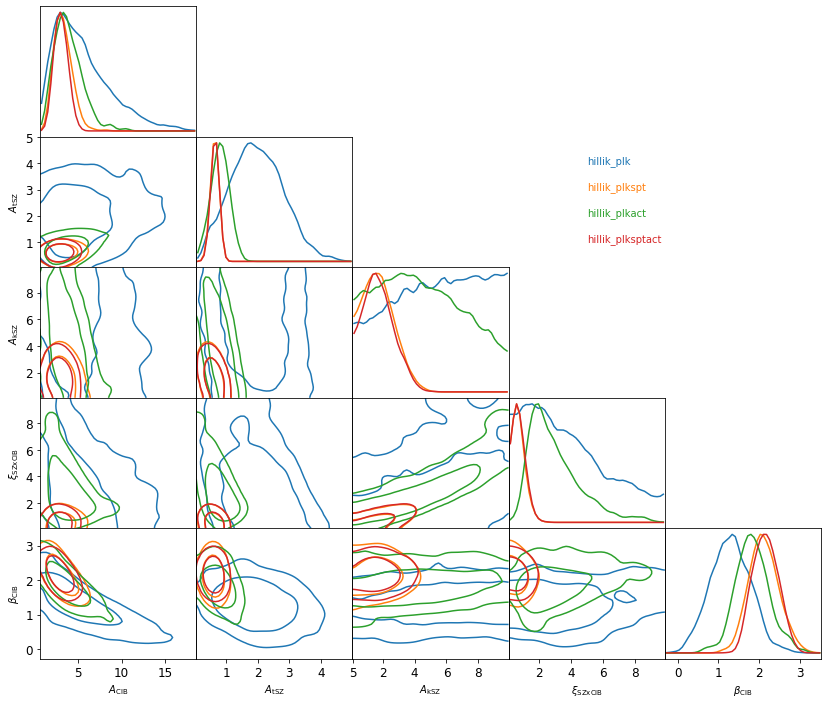

In [6]:
#extra-gal fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

## Alens

In [7]:
runnames = ['hillik_plk_Alens','hillik_plk_act_Alens','hillik_plk_spt_Alens','hillik_plk_spt_act_Alens']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.8, nelts=20000) for run in runnames]

hillik_plk_Alens: 254865  216172  174743  242400 
hillik_plk_act_Alens: 786499  568111  917379  713772 
hillik_plk_spt_Alens: 420170  704554  530800  565174 
hillik_plk_spt_act_Alens: 367951  477047  582509  624513 


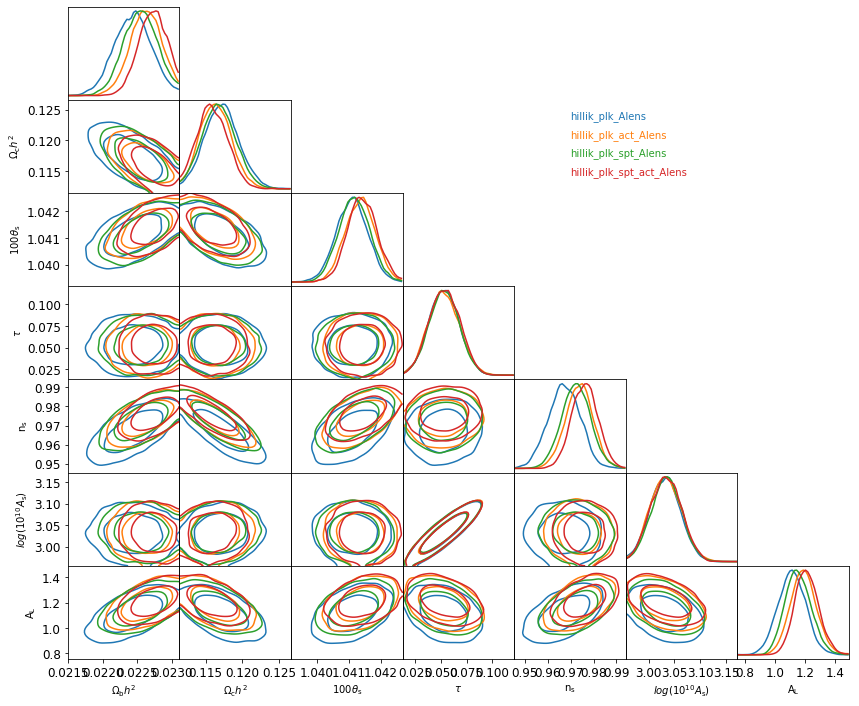

In [8]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA','Alens']
fig=MCtools.triangle( chains, listpar, labels=runnames)

In [9]:
print( "%35s %28s %28s %28s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

                   hillik_plk_Alens         hillik_plk_act_Alens         hillik_plk_spt_Alens     hillik_plk_spt_act_Alens
ombh2           =  0.022445 +/- 0.000275  |   0.022638 +/- 0.000237  |   0.022556 +/- 0.000256  |   0.022740 +/- 0.000220
omch2           =  0.117135 +/- 0.002389  |   0.116258 +/- 0.002159  |   0.116672 +/- 0.002352  |   0.115753 +/- 0.002166
theta           =  1.041109 +/- 0.000493  |   1.041375 +/- 0.000475  |   1.041182 +/- 0.000487  |   1.041424 +/- 0.000461
tau             =  0.052741 +/- 0.014707  |   0.052417 +/- 0.015296  |   0.053107 +/- 0.014539  |   0.053310 +/- 0.015095
ns              =  0.967184 +/- 0.007031  |   0.974019 +/- 0.005933  |   0.972492 +/- 0.006270  |   0.976347 +/- 0.005784
logA            =  3.031076 +/- 0.029955  |   3.031858 +/- 0.030854  |   3.034197 +/- 0.029681  |   3.033088 +/- 0.030669
Alens           =  1.113628 +/- 0.091688  |   1.189478 +/- 0.084439  |   1.151971 +/- 0.084874  |   1.210236 +/- 0.077044


In [10]:
for i in range(len(chains)):
    m,s = MCtools.MaxPosterior( chains[i], 'Alens', symmetrical=True)
    print("%4.3f +/- %4.3f" % (m,s), "(%4.2fσ)" % ((m-1)/s), runnames[i])

1.114 +/- 0.092 (1.24σ) hillik_plk_Alens
1.189 +/- 0.084 (2.24σ) hillik_plk_act_Alens
1.152 +/- 0.085 (1.79σ) hillik_plk_spt_Alens
1.210 +/- 0.077 (2.73σ) hillik_plk_spt_act_Alens
